<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import regex as re

def split_chars(text):
    return re.findall(r".", text)

In [2]:
chars = split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]

['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [3]:
# [\w]+ will grab consecutive non-whitespace characters
# [.,!?;] can match the punctuation marks between the brackets.
def split_words(text):
    return re.findall(r"[\w]+|[.,!?;]", text)

In [4]:
split_words("The quick brown fox jumped over the dog.")

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'dog', '.']

In [5]:
vocabulary = {
    "[UNK]": 0,
    "the": 1,
    "quick": 2,
    "brown": 3,
    "fox": 4,
    "jumped": 5,
    "over": 6,
    "dog": 7,
    ".": 8,
}

words = split_words("The quick brown fox jumped over the lazy dog.")
indices = [vocabulary.get(word, 0) for word in words]

# Both 'The' and 'lazy' are classified as unknows "UNK".
# Note 'The' and 'the' are different. (Capitalized vs non-capitalized)
print(indices)

[0, 2, 3, 4, 5, 6, 1, 0, 7, 8]


In [6]:
# Character and word tokenization

In [7]:
class CharTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]


    def standardize(self, inputs):
        return inputs.lower()


    def split(self, inputs):
        return re.findall(r".", inputs)


    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]


    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)

        return indices

In [8]:
import collections

def compute_char_vocabulary(inputs, max_size):
    char_counts = collections.Counter()

    for x in inputs:
        x = x.lower()
        tokens = re.findall(r".", x)
        char_counts.update(tokens)

    vocabulary = ["[UNK]"]
    most_common = char_counts.most_common(max_size - len(vocabulary))

    for token, count in most_common:
        vocabulary.append(token)

    return dict((token, i) for i, token in enumerate(vocabulary))

In [9]:
class WordTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]


    def standardize(self, inputs):
        return inputs.lower()


    def split(self, inputs):
        return re.findall(r"[\w]+|[.,!?;]", inputs)


    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]


    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)

        return indices

In [10]:
def compute_word_vocabulary(inputs, max_size):
    word_counts = collections.Counter()

    for x in inputs:
        x = x.lower()
        tokens = re.findall(r"[\w]+|[.,!?;]", x)
        word_counts.update(tokens)

    vocabulary = ["[UNK]"]
    most_common = word_counts.most_common(max_size - len(vocabulary))

    for token, count in most_common:
        vocabulary.append(token)

    return dict((token, i) for i, token in enumerate(vocabulary))

In [11]:
import keras

filename = keras.utils.get_file(
    origin="https://www.gutenberg.org/cache/epub/2701/pg2701.txt",
)

moby_dick = list(open(filename, "r"))

1276263/1276263 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [12]:
vocabulary = compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer = CharTokenizer(vocabulary)

In [13]:
print("Vocabulary length:", len(vocabulary))
print("Vocabulary start:", list(vocabulary.keys())[:10])
print("Vocabulary end:", list(vocabulary.keys())[-10:])
print("Line length:", len(char_tokenizer(
    "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Vocabulary length: 79
Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']
Vocabulary end: ['ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â', '%', '+']
Line length: 63


In [14]:
# Byte-pair encoding

In [15]:
data = [
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]

In [16]:
def count_and_split_words(data):
    counts = collections.Counter()

    for line in data:
        line = line.lower()

        for word in re.findall(r"[\w]+|[.,!?;]", line):
            chars = re.findall(r".", word)
            split_word = " ".join(chars)
            counts[split_word] += 1

    return dict(counts)

counts = count_and_split_words(data)

In [17]:
counts

{'t h e': 3,
 'q u i c k': 2,
 'b r o w n': 3,
 'f o x': 2,
 's l o w': 1,
 'f o x h o u n d': 1}

In [18]:
def count_pairs(counts):
    pairs = collections.Counter()

    for word, freq in counts.items():
        symbols = word.split()

        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq

    return pairs

def merge_pair(counts, first, second):
    # Matches an unmerged pair
    split = re.compile(f"(?<!\S){first} {second}(?!\S)")

    # Replaces all occurances with a merged version
    merged = f"{first}{second}"

    return {split.sub(merged, word): count for word, count in counts.items()}

for i in range(10):
    pairs = count_pairs(counts)
    first, second = max(pairs, key=pairs.get)
    counts = merge_pair(counts, first, second)

    print(list(counts.keys()))

['t h e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['th e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'br ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'fo x', 's l ow', 'fo x h o u n d']
['the', 'q u i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qu i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qui c k', 'brown', 'fox', 's l ow', 'fox h o u n d']


<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_899/65456570.py:14: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")
/tmp/ipykernel_899/65456570.py:14: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")


In [19]:
def compute_sub_word_vocabulary(dataset, vocab_size):
    counts = count_and_split_words(dataset)

    char_counts = collections.Counter()

    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]

    most_common = char_counts.most_common()
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    merges = []

    while len(vocab) < vocab_size:
        pairs = count_pairs(counts)

        if not pairs:
            break

        first, second = max(pairs, key=pairs.get)
        counts = merge_pair(counts, first, second)
        vocab.append(f"{first}{second}")
        merges.append(f"{first} {second}")

    vocab = dict((token, index) for index, token in enumerate(vocab))
    merges = dict((token, rank) for rank, token in enumerate(merges))

    return vocab, merges

In [20]:
class SubWordTokenizer:
    def __init__(self, vocabulary, merges):
        self.vocabulary = vocabulary
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]


    def standardize(self, inputs):
        return inputs.lower()


    def bpe_merge(self, word):
        while True:
            # Matches all symbol pairs in the text
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)

            if not pairs:
                break

            # We apply merge rules in "rank" order. More frequent pairs are merged first.
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))

            if best not in self.merges:
                break

            first, second = best.split()
            split = re.compile(f"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)

        return word


    def split(self, inputs):
        tokens = []

        # Split words
        for word in re.findall(r"[\w]+|[.,!?;]", inputs):
            # Joins all characters will a space
            word = " ".join(re.findall(r".", word))

            # Applies byte-pair encoding merge rules
            word = self.bpe_merge(word)
            tokens.extend(word.split())

        return tokens


    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]


    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)

        return indices

<>:27: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_899/377290133.py:27: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")
/tmp/ipykernel_899/377290133.py:27: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")


In [21]:
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2_000)
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges)

In [22]:
print("Vocabulary length:", len(vocabulary))
print("Vocabulary start:", list(vocabulary.keys())[:10])
print("Vocabulary end:", list(vocabulary.keys())[-7:])
print("Line length:", len(sub_word_tokenizer(
    "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Vocabulary length: 2000
Vocabulary start: ['[UNK]', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h', 'r']
Vocabulary end: ['mariners', 'height', 'certainly', 'sor', 'sist', 'similar', 'aught']
Line length: 16


In [23]:
# Loading the IMDb classification dataset
import os, pathlib, shutil, random

zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


In [24]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/root/.keras/datasets/imdb/aclImdb/test/neg
/root/.keras/datasets/imdb/aclImdb/test/pos
/root/.keras/datasets/imdb/aclImdb/train/unsup
/root/.keras/datasets/imdb/aclImdb/train/neg
/root/.keras/datasets/imdb/aclImdb/train/pos


In [25]:
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [26]:
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

# Moves the test data unaltered
shutil.copytree(imdb_extract_dir / "test", test_dir)

# Splits the training data into a train set and a validation set
val_percentage = 0.2

for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)
    num_val_samples = int(len(src_files) * val_percentage)

    os.makedirs(val_dir / category)

    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)

    os.makedirs(train_dir / category)

    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)

In [27]:
from keras.utils import text_dataset_from_directory

batch_size = 32

train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [28]:
# Training a bag-of-words model

In [29]:
from keras import layers

max_tokens = 20_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,

    # Learns a word-level vocabulary
    split="whitespace",
    output_mode="multi_hot",
)

train_ds_no_labels = train_ds.map(lambda x, y: x)
text_vectorization.adapt(train_ds_no_labels)

bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [30]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())

print(x.shape)
print(y.shape)

(32, 20000)
(32,)


In [31]:
def build_linear_classifier(max_tokens, name):
    inputs = keras.Input(shape=(max_tokens,))
    outputs = layers.Dense(1, activation="sigmoid")(inputs)

    model = keras.Model(inputs, outputs, name=name)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model

model = build_linear_classifier(max_tokens, "bag_of_words_classifier")

In [32]:
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)

history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8383 - loss: 0.4578 - val_accuracy: 0.8804 - val_loss: 0.3585
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9086 - loss: 0.2923 - val_accuracy: 0.8892 - val_loss: 0.3067
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9291 - loss: 0.2345 - val_accuracy: 0.8928 - val_loss: 0.2868
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9429 - loss: 0.1989 - val_accuracy: 0.8928 - val_loss: 0.2775
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9530 - loss: 0.1734 - val_accuracy: 0.8920 - val_loss: 0.2731
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9609 - loss: 0.1535 - val_accuracy: 0.8926 - val_loss: 0.2716
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9668 - loss: 0.1373 - val_accuracy: 0.8908 - val_loss: 0.2716
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9717 - loss: 0.1237 - val_accuracy: 

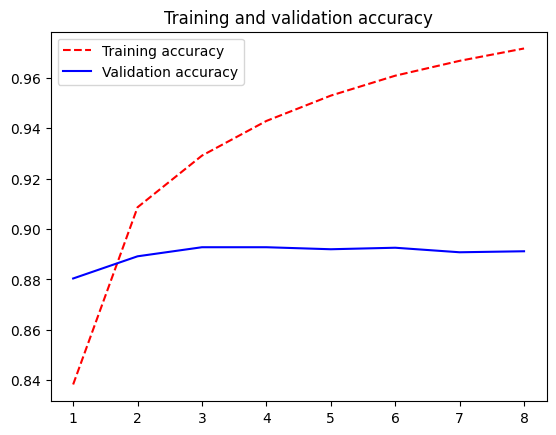

In [34]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [35]:
test_loss, test_acc = model.evaluate(bag_of_words_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8875 - loss: 0.2824


0.8875200152397156

In [36]:
# Training a bigram model

In [37]:
max_tokens = 30_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,

    # Learns a word-level vocabulary
    split="whitespace",
    output_mode="multi_hot",

    # Considers all unigrams and bigrams
    ngrams=2,
)

text_vectorization.adapt(train_ds_no_labels)

bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [38]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [39]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('most'),
 np.str_('how'),
 np.str_('dont'),
 np.str_('him'),
 np.str_('it was'),
 np.str_('one of'),
 np.str_('then'),
 np.str_('for the')]

In [40]:
model = build_linear_classifier(max_tokens, "bigram_classifier")

model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8640 - loss: 0.3985 - val_accuracy: 0.8922 - val_loss: 0.3060
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9366 - loss: 0.2219 - val_accuracy: 0.8966 - val_loss: 0.2700
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9617 - loss: 0.1624 - val_accuracy: 0.9002 - val_loss: 0.2585
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9754 - loss: 0.1256 - val_accuracy: 0.8994 - val_loss: 0.2553
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9838 - loss: 0.0999 - val_accuracy: 0.8994 - val_loss: 0.2553
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9905 - loss: 0.0806 - val_accuracy: 0.8998 - val_loss: 0.2587


In [41]:
test_loss, test_acc = model.evaluate(bigram_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9012 - loss: 0.2514


0.9012399911880493

In [42]:
max_length = 600
max_tokens = 30_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,

    # Learns a word-level vocabulary
    split="whitespace",

    # Outputs a integer sequence of token IDs
    output_mode="int",

    # Pads and truncates to 600 tokens
    output_sequence_length=max_length,
)

text_vectorization.adapt(train_ds_no_labels)

sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [43]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(32, 600)

In [44]:
x

array([[    2,   797, 13611, ...,    90,   362,    16],
       [  614,     9,    68, ...,     0,     0,     0],
       [  195,    42,   107, ...,     0,     0,     0],
       ...,
       [   39,   154,  2087, ...,     0,     0,     0],
       [    3,   974,     4, ...,     0,     0,     0],
       [    2, 13483,  4443, ...,     0,     0,     0]])

In [45]:
# Training a recurrent model

In [46]:
from keras import ops

class OneHotEncoding(keras.Layer):
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth


    def call(self, inputs):
        # Flattens the inputs
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])

        # Builds an identity matrix with all possible one-hot vectors
        one_hot_vectors = ops.eye(self.depth)

        # Uses our input token IDs to gather the correct vector for each token
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)

        # Unflattens the output
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)

In [47]:
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

TensorShape([32, 600, 30000])

In [48]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")

x = one_hot_encoding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs, name="lstm_with_one_hot")

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [49]:
model.summary()

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot_encoding                │ (None, 600, 30000)     │             0 │
│ (OneHotEncoding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │    15,393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# model.fit(
#     sequence_train_ds,
#     validation_data=sequence_val_ds,
#     epochs=10,
#     callbacks=[early_stopping],
# )

In [51]:
# test_loss, test_acc = model.evaluate(sequence_test_ds)
# test_acc

In [52]:
# Understanding word embeddings

In [53]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")

x = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs, name="lstm_with_embedding")

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [54]:
model.summary()

Model: "lstm_with_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 600)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 600, 64)   │  1,920,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 600)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,986,177 (7.58 MB)

 Trainable params: 1,986,177 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.7842 - loss: 0.4469 - val_accuracy: 0.8564 - val_loss: 0.3536
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9154 - loss: 0.2196 - val_accuracy: 0.8734 - val_loss: 0.3021
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8436 - loss: 0.3709


0.8435999751091003

In [56]:
# Pretraining a word embedding

In [57]:
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

In [58]:
import tensorflow as tf

# Words to the left or right of label
context_size = 4

# Total window size
window_size = 9

def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)

    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)

    return tf.data.Dataset.from_tensor_slices(windowed_tokens)


def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[4]

    return bag, label

In [59]:
# Uses all training data, including the unsup/ directory
dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)

# Drops label
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)

# Tokenizes
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)

# Creates context windows
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)

# Splits middle wonder into a label
dataset = dataset.map(split_label, num_parallel_calls=8)

Found 75000 files belonging to 3 classes.


In [60]:
hidden_dim = 64
inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)

x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(max_tokens, activation="sigmoid")(x)

cbow_model = keras.Model(inputs, outputs)

cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [61]:
cbow_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 8, 64)          │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30000)          │     1,950,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,870,000 (14.76 MB)

 Trainable params: 3,870,000 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=4)

Epoch 1/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 476s 29ms/step - loss: 6.3307 - sparse_categorical_accuracy: 0.1024
Epoch 2/4
   18/16503 ━━━━━━━━━━━━━━━━━━━━ 2:36 10ms/step - loss: 6.0730 - sparse_categorical_accuracy: 0.1252

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 163s 10ms/step - loss: 5.8783 - sparse_categorical_accuracy: 0.1292
Epoch 3/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 165s 10ms/step - loss: 5.7376 - sparse_categorical_accuracy: 0.1355
Epoch 4/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 164s 10ms/step - loss: 5.6678 - sparse_categorical_accuracy: 0.1378


In [63]:
# Using the pretrained embedding for classification

In [64]:
inputs = keras.Input(shape=(max_length,))
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)

x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [65]:
# Apply our embedding weights from the CBOW embedding layer to the LSTM embedding layer.
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

<Variable path=embedding_1/embeddings, shape=(30000, 64), dtype=float32, value=[[-0.01778119 -0.0288184  -0.01192986 ... -0.04750962 -0.04386774
  -0.02580669]
 [ 0.61663425 -0.18943939 -0.43349385 ...  0.3111609  -0.0622015
   0.14591116]
 [-0.5879006   0.12126074  0.06865761 ... -0.3603421   0.19511679
  -0.07844648]
 ...
 [-0.20330305 -0.30561128 -0.44348925 ... -0.3920488   0.09664857
  -0.18611644]
 [-0.68577576 -0.38958147 -0.24104479 ... -0.76919806  0.34022638
   0.38290206]
 [ 0.13660061  0.8867038   0.309815   ... -0.50084215 -0.22584236
   0.22332107]]>

In [66]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.7678 - loss: 0.4836 - val_accuracy: 0.8528 - val_loss: 0.3581
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8639 - loss: 0.3233 - val_accuracy: 0.8534 - val_loss: 0.3907


In [67]:
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8460 - loss: 0.3633


0.8460400104522705